#Samia Rehan — MobileNetV2 + SSD
## Model 4: Lightweight Detection in TensorFlow/Keras

We train **MobileNetV2 + SSD** - Google's lightweight object detection model - to detect Coca-Cola, Sprite, and Fanta bottles on retail shelves.

**MobileNetV2** is the backbone (feature extractor). It is designed for mobile and edge devices —
much smaller and faster than ResNet50, but slightly less accurate.

**SSD (Single Shot MultiBox Detector)** is the detection head. Unlike our ResNet50 model
that detected one box per image, SSD can detect **multiple bottles in one shot** without separate region proposal step.


###Notebook Roadmap
| Step | What Happens |
|------|--------------|
| 1 | Setup — install TensorFlow, check GPU |
| 2 | Download dataset from Roboflow |
| 3 | Convert dataset to TFRecord format |
| 4 | Explore and visualise the data |
| 5 | Build MobileNetV2 + SSD model |
| 6 | Train the model |
| 7 | Evaluate — loss curves, mAP, per-class results |
| 8 | Run inference on shelf images |
| 9 | Shelf metrics — SOS, OSA, Planogram |
| 10 | Save and download best weights |

---

###BEFORE YOU RUN ANYTHING:
> **Runtime → Change Runtime Type → Hardware Accelerator → T4 GPU → Save**

---

# STEP 1 — Setup and  Installation


In [1]:
print("Installing libraries...")
!pip install roboflow tensorflow-hub opencv-python seaborn --quiet
import os, json, time, copy, random, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import defaultdict
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers, callbacks
import yaml

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
print("ENVIRONMENT CHECK:")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {len(gpus)}")
if gpus:
    for g in gpus:
        print(f"GPU               : {g.name}")
    print("Ready to train")
else:
    print("No GPU found")
    print(" → Runtime → Change Runtime Type → T4 GPU")


Installing libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.9 MB/s eta 0:00:00
ENVIRONMENT CHECK:
TensorFlow version : 2.20.0
GPUs available     : 1
GPU               : /physical_device:GPU:0
Ready to train


---
# STEP 2 — Download the Dataset from Roboflow

Same dataset  — **soda-bottles-haga**.
Three classes: `coca-cola`, `sprite`, `fanta`.

We download in **YOLOv8 format** (images + .txt label files) and then
convert to TensorFlow's format in Step 3.



In [2]:
from roboflow import Roboflow
from google.colab import files as colab_files
API_KEY = "G2NmxkC2Za5dtJ47ID3a"
rf      = Roboflow(api_key=API_KEY)
project = rf.workspace("rf20-vl").project("soda-bottles-haga")
dataset = project.version(1).download("yolov8")
DATASET_DIR = dataset.location
with open(os.path.join(DATASET_DIR, "data.yaml")) as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg['names']   #['coca-cola', 'sprite', 'fanta']
NUM_CLASSES = len(CLASS_NAMES)
COLORS_MAP  = {'coca-cola': '#E8192C', 'sprite': '#00A14B', 'fanta': '#FF6600'}

print("\nDataset downloaded.")
print(f"   Classes : {CLASS_NAMES}")
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(img_dir):
        n = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png','.jpeg'))])
        print(f"   {split:8s}: {n} images")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to soda-bottles-haga-1 in yolov8:: 100%|██████████| 4510/4510 [00:02<00:00, 2129.34it/s]


Dataset downloaded.
   Classes : ['coca-cola', 'fanta', 'sprite']
   train   : 1574 images
   valid   : 449 images
   test    : 226 images


---
# STEP 3 — Build TensorFlow Data Pipeline

### Why Do We Need This?
TensorFlow uses `tf.data.Dataset` — an efficient pipeline that:
- Loads images in batches
- Applies augmentations on the fly
- Prefetches the next batch while GPU trains on the current one

### What Is a tf.data.Dataset?
Think of it like a conveyor belt. The GPU trains on batch 1 while
the CPU is already loading and preparing batch 2. This keeps the GPU
busy 100% of the time instead of waiting for data.

### Label Format
YOLO labels: `class_id cx cy bw bh` (all normalised 0–1)
We keep this format — just parse it into TensorFlow tensors.

In [3]:
IMG_SIZE   = 320    # MobileNetV2 works well at 320×320 (faster than 640)
BATCH_SIZE = 16

def parse_yolo_label(label_path):
    boxes, cls_ids = [], []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_ids.append(int(parts[0]))
                    boxes.append(list(map(float, parts[1:5])))
    if not boxes:
        return None, None
    # Pick largest box by area (bw * bh)
    largest_idx = max(range(len(boxes)), key=lambda i: boxes[i][2]*boxes[i][3])
    return cls_ids[largest_idx], boxes[largest_idx]


#Build file lists
def get_split_data(split):
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    img_paths, cls_ids, bbox_list = [], [], []

    for fname in sorted(os.listdir(img_dir)):
        if not fname.endswith(('.jpg','.png','.jpeg')):
            continue
        lbl_path = os.path.join(lbl_dir, Path(fname).stem + '.txt')
        cls_id, box = parse_yolo_label(lbl_path)
        if cls_id is None:
            continue
        img_paths.append(os.path.join(img_dir, fname))
        cls_ids.append(cls_id)
        bbox_list.append(box)

    return img_paths, cls_ids, bbox_list


# TF preprocessing functions
# MobileNetV2 expects pixels in [-1, 1] range (NOT [0,1])
# tf.keras.applications.mobilenet_v2.preprocess_input does this automatically

def load_and_preprocess(img_path, cls_id, bbox, augment=False):
    # Load
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # Augmentations (training only)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, lower=0.7, upper=1.3)
        img = tf.image.random_saturation(img, lower=0.7, upper=1.4)
        img = tf.clip_by_value(img, 0, 255)

    # MobileNetV2 preprocessing: scales [0,255] → [-1,1]
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, cls_id, bbox

def make_dataset(split, augment=False):
    """Build a tf.data.Dataset for a given split."""
    img_paths, cls_ids, bboxes = get_split_data(split)
    print(f"   {split:8s}: {len(img_paths)} samples loaded")

    # Convert to tensors
    img_paths_t = tf.constant(img_paths)
    cls_ids_t   = tf.constant(cls_ids,  dtype=tf.int32)
    bboxes_t    = tf.constant(bboxes,   dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((img_paths_t, cls_ids_t, bboxes_t))
    if augment:
        ds = ds.shuffle(buffer_size=500, seed=SEED)
    ds = ds.map(
        lambda path, cls, box: load_and_preprocess(path, cls, box, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # prefetch next batch while GPU trains
    return ds


#Create datasets
print(" Building TensorFlow datasets...")
train_ds = make_dataset('train', augment=True)
val_ds   = make_dataset('valid', augment=False)
test_ds  = make_dataset('test',  augment=False)

print(f"\nDatasets ready.")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Image size : {IMG_SIZE}×{IMG_SIZE}")
print(f"   Input range: [-1, 1]  (MobileNetV2 format)")

 Building TensorFlow datasets...
   train   : 1574 samples loaded
   valid   : 449 samples loaded
   test    : 226 samples loaded

Datasets ready.
   Batch size : 16
   Image size : 320×320
   Input range: [-1, 1]  (MobileNetV2 format)


---
# STEP 4 — Explore & Visualise the Data

Always look at your data before training — check that labels are correct
and images look reasonable.

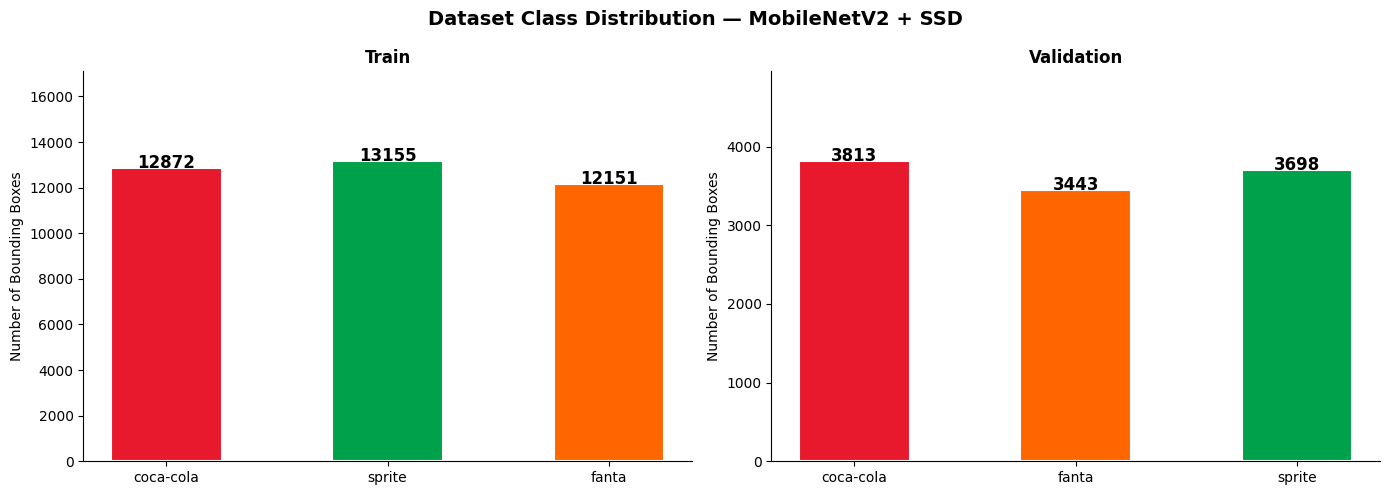

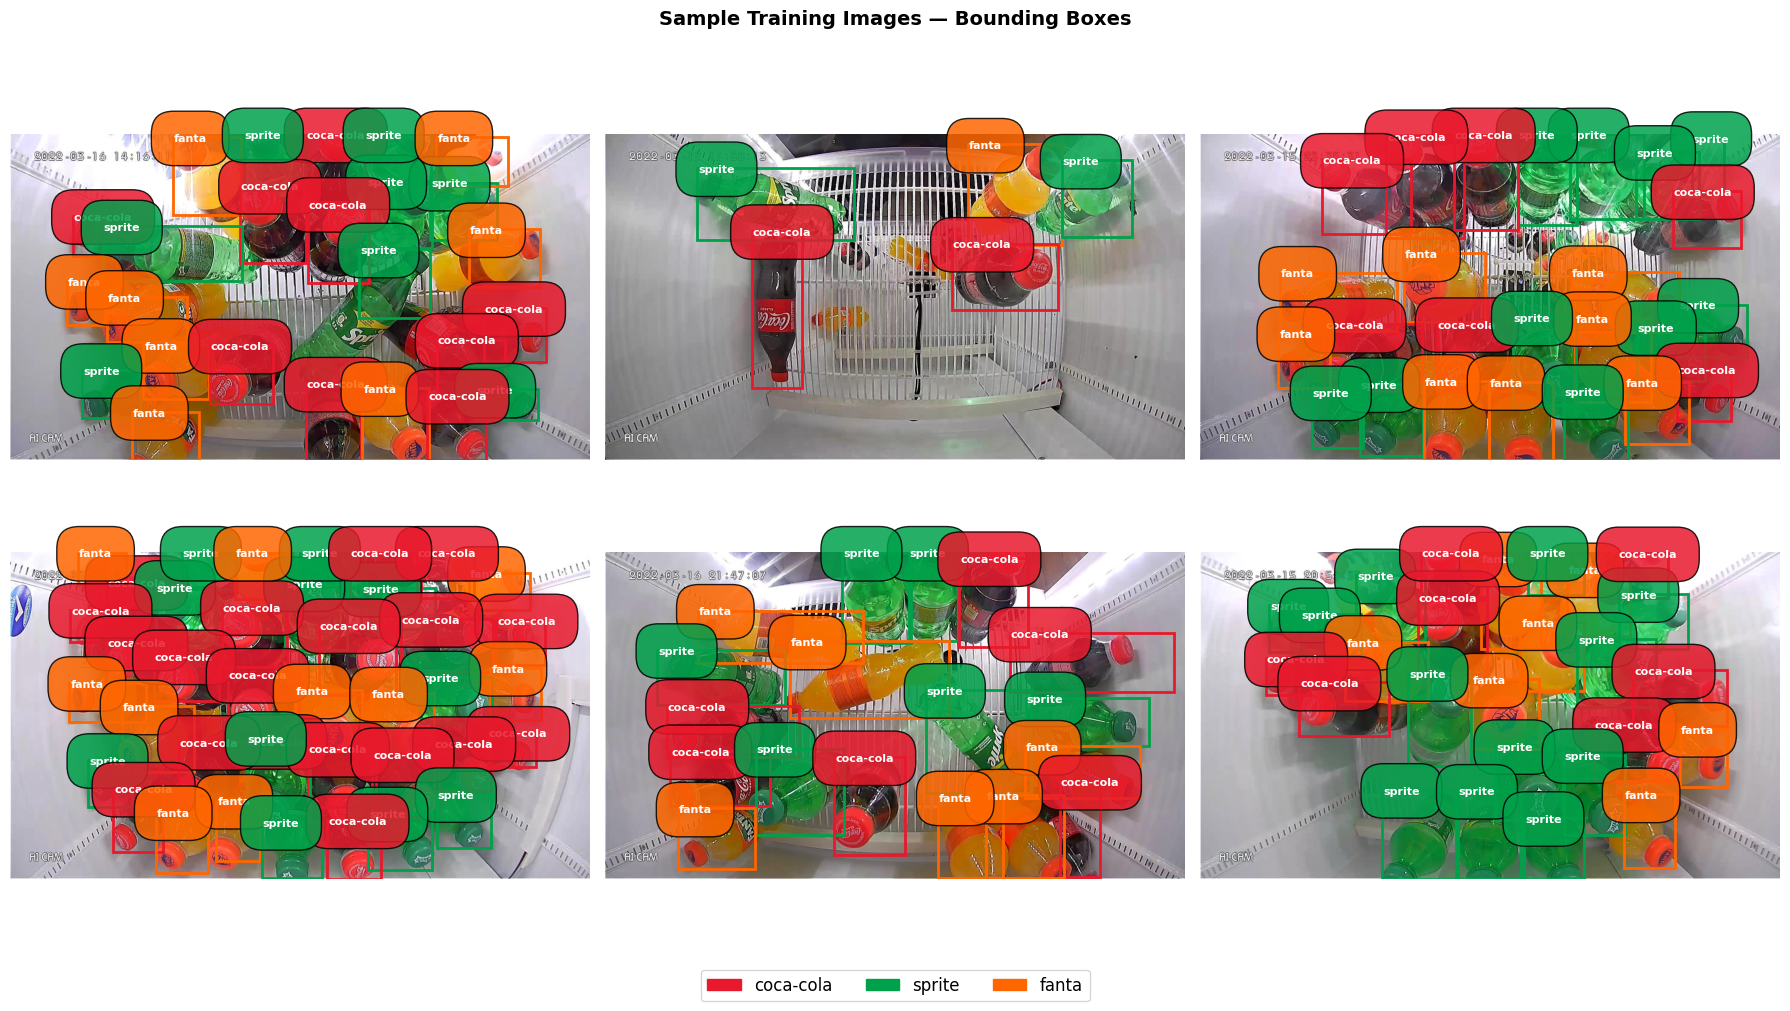

Plots saved


In [4]:
#Class distribution
def count_labels(split):
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    counts  = defaultdict(int)
    if not os.path.exists(lbl_dir):
        return counts
    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[CLASS_NAMES[int(parts[0])]] += 1
    return counts

train_counts = count_labels('train')
val_counts   = count_labels('valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Class Distribution — MobileNetV2 + SSD', fontsize=14, fontweight='bold')

for ax, (counts, title) in zip(axes, [(train_counts,'Train'), (val_counts,'Validation')]):
    names  = list(counts.keys())
    values = list(counts.values())
    colors = [COLORS_MAP.get(n,'#999') for n in names]
    bars   = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Bounding Boxes')
    ax.set_ylim(0, max(values)*1.3 if values else 10)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(val), ha='center', fontweight='bold', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#Sample images with boxes
train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')
train_lbl_dir = os.path.join(DATASET_DIR, 'train', 'labels')
all_imgs      = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg','.png'))]
sample_imgs   = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sample Training Images — Bounding Boxes', fontsize=14, fontweight='bold')

for ax, img_name in zip(axes.flatten(), sample_imgs):
    img  = Image.open(os.path.join(train_img_dir, img_name)).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    lbl_path = os.path.join(train_lbl_dir, Path(img_name).stem + '.txt')
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 5: continue
                cls_id      = int(p[0])
                cx,cy,bw,bh = map(float, p[1:5])
                x1 = (cx-bw/2)*W; y1 = (cy-bh/2)*H
                name  = CLASS_NAMES[cls_id]
                color = COLORS_MAP.get(name,'#999')
                ax.add_patch(patches.Rectangle((x1,y1), bw*W, bh*H,
                             linewidth=2, edgecolor=color, facecolor='none'))
                ax.text(x1+3, y1+14, name, fontsize=8, color='white', fontweight='bold',
                        bbox=dict(facecolor=color, alpha=0.85, pad=2, boxstyle='round'))
    ax.axis('off')

handles = [patches.Patch(color=c, label=n) for n,c in COLORS_MAP.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=12,
           bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved")

---
# STEP 5 — Build the MobileNetV2 + SSD Model


### What Is MobileNetV2?
MobileNetV2 is a CNN designed by Google specifically for **speed and efficiency**.
It uses **depthwise separable convolutions** — a trick that does the same job as
normal convolutions but with far fewer calculations.

### What Is SSD?
SSD (Single Shot MultiBox Detector) means the model detects objects
in a **single forward pass** — no separate region proposal step needed.
This is what makes it fast enough for mobile devices.


In [5]:
def build_mobilenet_ssd(num_classes=3, img_size=320, freeze_backbone=True):

    # Load MobileNetV2 backbone
    # include_top=False  → remove the ImageNet classification layer
    # input_shape        → must match our image size
    # weights='imagenet' → use pre-trained weights (transfer learning)
    backbone = tf.keras.applications.MobileNetV2(
        input_shape = (img_size, img_size, 3),
        include_top = False,
        weights     = 'imagenet'
    )

    # Freeze backbone for Phase 1
    # Frozen layers won't update during Phase 1 training
    backbone.trainable = not freeze_backbone

    total_layers    = len(backbone.layers)
    trainable_count = sum(1 for l in backbone.layers if l.trainable)
    if freeze_backbone:
        print(f"  Backbone FROZEN — {total_layers} layers locked")
    else:
        print(f"  Backbone UNFROZEN — {total_layers} layers trainable")

    # Build model using Functional API
    inputs   = tf.keras.Input(shape=(img_size, img_size, 3))
    x        = backbone(inputs, training=False)  # training=False keeps BN frozen
    features = layers.GlobalAveragePooling2D()(x)   # (batch, 1280)

    #Classification branch
    cls = layers.Dense(256, activation='relu')(features)
    cls = layers.Dropout(0.4)(cls)
    cls = layers.Dense(128, activation='relu')(cls)
    cls_output = layers.Dense(num_classes, activation='softmax', name='classification')(cls)

    #Bounding box branch
    # Sigmoid ensures all 4 outputs stay in [0, 1]
    box = layers.Dense(256, activation='relu')(features)
    box = layers.Dropout(0.4)(box)
    box = layers.Dense(128, activation='relu')(box)
    box_output = layers.Dense(4, activation='sigmoid', name='bbox')(box)

    #Create model with two outputs
    model = Model(
        inputs  = inputs,
        outputs = {'classification': cls_output, 'bbox': box_output}
    )

    return model
# Build model — Phase 1: frozen backbone
print("Building MobileNetV2 + SSD model...")
model = build_mobilenet_ssd(num_classes=NUM_CLASSES, img_size=IMG_SIZE, freeze_backbone=True)

#Print parameter count
total_params     = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])

print(f"\nModel Summary:")
print(f"Total parameters     : {total_params:>12,}")
print(f"Trainable (Phase 1)  : {trainable_params:>12,}  ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen (backbone)    : {total_params-trainable_params:>12,}")
print()
print("Model input/output shapes:")
model.summary(line_length=80)

Building MobileNetV2 + SSD model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Backbone FROZEN — 154 layers locked

Model Summary:
Total parameters     :    2,980,551
Trainable (Phase 1)  :      722,567  (24.2%)
Frozen (backbone)    :    2,257,984

Model input/output shapes:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, 320, 320,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ mobilenetv2_1.00_224  │ (None, 10, 10,    │   2,257,984 │ input_layer_1[0][… │
│ (Functional)          │ 1280)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ global_average_pooli… │ (None, 1280)      │           0 │ mobilenetv2_1.00_… │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_2 (Dense)       │ (None, 256)       │     327,936 │ global_average_po… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, 256)       │     327,936 │ global_average_po… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_1 (Dropout)   │ (None, 256)       │           0 │ dense_2[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, 256)       │           0 │ dense[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_3 (Dense)       │ (None, 128)       │      32,896 │ dropout_1[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_1 (Dense)       │ (None, 128)       │      32,896 │ dropout[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bbox (Dense)          │ (None, 4)         │         516 │ dense_3[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ classification        │ (None, 3)         │         387 │ dense_1[0][0]      │
│ (Dense)               │                   │             │                    │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 2,980,551 (11.37 MB)

 Trainable params: 722,567 (2.76 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
# STEP 6 — Train the Model

## Two-Phase Training

### Phase 1 — Frozen Backbone (Epochs 1–10)
Only train the new classification and bounding box heads.
Backbone stays fixed — pre-trained ImageNet features are preserved.

### Phase 2 — Partial Unfreeze (Epochs 11–30)
Unfreeze the last 30 layers of MobileNetV2 so they adapt to soda bottles.
Use a much smaller learning rate to avoid overwriting pre-trained weights.

## Loss Functions
- **Sparse Categorical Crossentropy** — for classification (which brand?)
- **Huber Loss** — for bounding box regression (similar to SmoothL1 in PyTorch)
- **Total Loss** = cls_loss + 5.0 × bbox_loss

In [6]:
# Loss Functions and Training Steps

#Count class frequencies from training labels
_, train_cls_ids, _ = get_split_data('train')
cls_counts = np.bincount(train_cls_ids, minlength=NUM_CLASSES)
print(f"   Class counts in train: {dict(zip(CLASS_NAMES, cls_counts))}")

# Class weight = total_samples / (num_classes × class_count)
# This penalises the model MORE for getting rare classes wrong
total = sum(cls_counts)
class_weights = {i: total / (NUM_CLASSES * count) for i, count in enumerate(cls_counts)}
print(f"   Class weights: { {CLASS_NAMES[i]: round(w,2) for i,w in class_weights.items()} }")

#Weighted loss function
def weighted_cls_loss(y_true, y_pred):
    """
    CrossEntropy loss that penalises mistakes on rare classes more heavily.
    coca-cola and sprite mistakes will cost more than fanta mistakes.
    """
    weights = tf.constant(
        [class_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32
    )
    # Get per-sample weight based on true class
    sample_weights = tf.gather(weights, tf.cast(y_true, tf.int32))
    base_loss      = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(base_loss * sample_weights)

cls_loss_fn  = weighted_cls_loss   # ← replaces SparseCategoricalCrossentropy
bbox_loss_fn = tf.keras.losses.Huber(delta=1.0)
BBOX_WEIGHT  = 5.0
print(" Weighted loss function applied")
bbox_loss_fn = tf.keras.losses.Huber(delta=1.0)
BBOX_WEIGHT  = 5.0
def compute_iou_tf(pred_boxes, gt_boxes):
    # Convert [cx,cy,bw,bh] → [x1,y1,x2,y2]
    p_x1 = pred_boxes[:,0] - pred_boxes[:,2]/2
    p_y1 = pred_boxes[:,1] - pred_boxes[:,3]/2
    p_x2 = pred_boxes[:,0] + pred_boxes[:,2]/2
    p_y2 = pred_boxes[:,1] + pred_boxes[:,3]/2

    g_x1 = gt_boxes[:,0] - gt_boxes[:,2]/2
    g_y1 = gt_boxes[:,1] - gt_boxes[:,3]/2
    g_x2 = gt_boxes[:,0] + gt_boxes[:,2]/2
    g_y2 = gt_boxes[:,1] + gt_boxes[:,3]/2

    ix1  = tf.maximum(p_x1, g_x1)
    iy1  = tf.maximum(p_y1, g_y1)
    ix2  = tf.minimum(p_x2, g_x2)
    iy2  = tf.minimum(p_y2, g_y2)

    inter  = tf.maximum(ix2-ix1, 0) * tf.maximum(iy2-iy1, 0)
    area_p = (p_x2-p_x1) * (p_y2-p_y1)
    area_g = (g_x2-g_x1) * (g_y2-g_y1)
    union  = area_p + area_g - inter + 1e-6
    return tf.reduce_mean(inter / union).numpy()


def train_step(model, optimizer, images, cls_labels, bbox_labels):
    with tf.GradientTape() as tape:
        outputs    = model(images, training=True)
        cls_preds  = outputs['classification']
        bbox_preds = outputs['bbox']
        cls_loss   = cls_loss_fn(cls_labels, cls_preds)
        bbox_loss  = bbox_loss_fn(bbox_labels, bbox_preds)
        total_loss = cls_loss + BBOX_WEIGHT * bbox_loss
    grads = tape.gradient(total_loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)   # prevent exploding gradients
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss, cls_loss, bbox_loss, cls_preds


def val_step(model, images, cls_labels, bbox_labels):
    outputs    = model(images, training=False)
    cls_preds  = outputs['classification']
    bbox_preds = outputs['bbox']
    cls_loss   = cls_loss_fn(cls_labels, cls_preds)
    bbox_loss  = bbox_loss_fn(bbox_labels, bbox_preds)
    total_loss = cls_loss + BBOX_WEIGHT * bbox_loss
    return total_loss, cls_loss, bbox_loss, cls_preds, bbox_preds


print("Loss functions and training steps defined")
print("cls_loss  : SparseCategoricalCrossentropy")
print("bbox_loss : Huber (delta=1.0)")
print("bbox_weight: 5.0")
print("@tf.function: disabled (supports Phase 1 → Phase 2 variable change)")

   Class counts in train: {'coca-cola': np.int64(453), 'fanta': np.int64(622), 'sprite': np.int64(499)}
   Class weights: {'coca-cola': np.float64(1.16), 'fanta': np.float64(0.84), 'sprite': np.float64(1.05)}
 Weighted loss function applied
Loss functions and training steps defined
cls_loss  : SparseCategoricalCrossentropy
bbox_loss : Huber (delta=1.0)
bbox_weight: 5.0
@tf.function: disabled (supports Phase 1 → Phase 2 variable change)


In [7]:
# PHASE 1 TRAINING — Frozen Backbone (Epochs 1–10)

PHASE1_EPOCHS = 10
LR_PHASE1     = 1e-3
# Adam optimizer — adapts learning rate per parameter automatically
optimizer_p1 = tf.keras.optimizers.Adam(learning_rate=LR_PHASE1)
# History storage
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'train_iou':[], 'val_iou':[], 'phase_boundary': None}
best_val_loss = float('inf')

print(" PHASE 1 TRAINING — Frozen Backbone")
print(f"   Epochs: {PHASE1_EPOCHS}   LR: {LR_PHASE1}   Batch: {BATCH_SIZE}")
print("="*70)
for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    print(f"\n Epoch {epoch}/{PHASE1_EPOCHS}")

    #Training loop
    train_losses, train_accs = [], []
    for batch_idx, (images, cls_labels, bbox_labels) in enumerate(train_ds):
        total_loss, cls_loss, bbox_loss, cls_preds = train_step(
            model, optimizer_p1, images, cls_labels, bbox_labels)

        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(cls_preds,1), tf.cast(cls_labels,tf.int64)), tf.float32)
        ).numpy()
        train_losses.append(total_loss.numpy())
        train_accs.append(acc)
        if (batch_idx + 1) % 15 == 0 or (batch_idx + 1) == len(train_ds):
            print(f"Batch [{batch_idx+1:>3}/{len(train_ds)}]  "
                  f"Loss: {np.mean(train_losses):.4f}  "
                  f"Acc: {np.mean(train_accs):.2%}")

    #Validation loop
    val_losses, val_accs, val_ious = [], [], []
    for images, cls_labels, bbox_labels in val_ds:
        total_loss, _, _, cls_preds, bbox_preds = val_step(
            model, images, cls_labels, bbox_labels)

        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(cls_preds,1), tf.cast(cls_labels,tf.int64)), tf.float32)
        ).numpy()
        iou = compute_iou_tf(bbox_preds.numpy(), bbox_labels.numpy())
        val_losses.append(total_loss.numpy())
        val_accs.append(acc)
        val_ious.append(iou)

    # Learning rate schedule (reduce on plateau)
    # Manually reduce LR if val_loss hasn't improved for 3 epochs
    val_loss_avg = np.mean(val_losses)
    if epoch > 3:
        recent = history['val_loss'][-3:]
        if all(val_loss_avg >= v for v in recent):
            old_lr = optimizer_p1.learning_rate.numpy()
            optimizer_p1.learning_rate.assign(old_lr * 0.5)
            print(f"   LR reduced: {old_lr:.6f} → {old_lr*0.5:.6f}")

    # Save best model
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        model.save_weights('best_model.weights.h5')   # save weights only
        print(f"   New best model saved! Val Loss: {best_val_loss:.4f}")
        # ← NO download here

    # Record history
    history['train_loss'].append(np.mean(train_losses))
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(np.mean(train_accs))
    history['val_acc'].append(np.mean(val_accs))
    history['train_iou'].append(0.0)
    history['val_iou'].append(np.mean(val_ious))

    elapsed = time.time() - t0
    print(f"   ─── Epoch {epoch} Summary ─── ({elapsed:.0f}s)")
    print(f"   Train → Loss: {np.mean(train_losses):.4f}  Acc: {np.mean(train_accs):.2%}")
    print(f"   Val   → Loss: {val_loss_avg:.4f}  Acc: {np.mean(val_accs):.2%}  IoU: {np.mean(val_ious):.3f}")

# Download once after Phase 1 ends
history['phase_boundary'] = PHASE1_EPOCHS
print(f"\n Phase 1 complete! Best val loss: {best_val_loss:.4f}")
colab_files.download('best_model.weights.h5')
print(" Phase 1 → best_model.weights.h5 downloaded!")

 PHASE 1 TRAINING — Frozen Backbone
   Epochs: 10   LR: 0.001   Batch: 16

 Epoch 1/10
Batch [ 15/99]  Loss: 1.2351  Acc: 41.25%
Batch [ 30/99]  Loss: 1.2407  Acc: 40.62%
Batch [ 45/99]  Loss: 1.2448  Acc: 40.69%
Batch [ 60/99]  Loss: 1.2412  Acc: 40.10%
Batch [ 75/99]  Loss: 1.2390  Acc: 38.00%
Batch [ 90/99]  Loss: 1.2390  Acc: 37.57%
Batch [ 99/99]  Loss: 1.2402  Acc: 37.10%
   New best model saved! Val Loss: 1.1388
   ─── Epoch 1 Summary ─── (93s)
   Train → Loss: 1.2402  Acc: 37.10%
   Val   → Loss: 1.1388  Acc: 43.97%  IoU: 0.066

 Epoch 2/10
Batch [ 15/99]  Loss: 1.0552  Acc: 51.67%
Batch [ 30/99]  Loss: 1.0864  Acc: 48.75%
Batch [ 45/99]  Loss: 1.1256  Acc: 45.00%
Batch [ 60/99]  Loss: 1.1337  Acc: 43.13%
Batch [ 75/99]  Loss: 1.1417  Acc: 40.92%
Batch [ 90/99]  Loss: 1.1422  Acc: 41.11%
Batch [ 99/99]  Loss: 1.1468  Acc: 40.61%
   New best model saved! Val Loss: 1.1211
   ─── Epoch 2 Summary ─── (59s)
   Train → Loss: 1.1468  Acc: 40.61%
   Val   → Loss: 1.1211  Acc: 35.13%  I

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Phase 1 → best_model.weights.h5 downloaded!


In [8]:
# PHASE 2 TRAINING — Unfreeze Last 30 Layers (Epochs 11–30)

PHASE2_EPOCHS = 20
LR_PHASE2     = 1e-4
UNFREEZE_LAST = 30   # number of backbone layers to unfreeze

#Unfreeze last N layers of the backbone
backbone_layer = model.layers[1]   # index 1 = MobileNetV2 in our model
backbone_layer.trainable = True

# Freeze all layers except the last UNFREEZE_LAST
for layer in backbone_layer.layers[:-UNFREEZE_LAST]:
    layer.trainable = False

newly_trainable = sum(1 for l in backbone_layer.layers if l.trainable)
print(f"   Unfrozen last {UNFREEZE_LAST} backbone layers ({newly_trainable} trainable)")
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"   Trainable params now: {trainable_params:,} / {model.count_params():,}")
print(f"   ({100*trainable_params/model.count_params():.1f}% of total)")

# Recompile with lower learning rate
optimizer_p2 = tf.keras.optimizers.Adam(learning_rate=LR_PHASE2)

print(f"\n PHASE 2 TRAINING — Partial Unfreeze")
print(f"   Epochs: {PHASE2_EPOCHS}   LR: {LR_PHASE2}")
print("="*70)

for epoch in range(PHASE1_EPOCHS + 1, PHASE1_EPOCHS + PHASE2_EPOCHS + 1):
    t0         = time.time()
    ep_display = epoch - PHASE1_EPOCHS
    print(f"\n Phase 2 — Epoch {ep_display}/{PHASE2_EPOCHS} (Global: {epoch})")

    # Cosine annealing LR decay
    cos_lr = LR_PHASE2 * (1 + math.cos(math.pi * (ep_display-1) / PHASE2_EPOCHS)) / 2
    optimizer_p2.learning_rate.assign(max(cos_lr, 1e-6))

    # Training loop
    train_losses, train_accs = [], []
    for batch_idx, (images, cls_labels, bbox_labels) in enumerate(train_ds):
        total_loss, cls_loss, bbox_loss, cls_preds = train_step(
            model, optimizer_p2, images, cls_labels, bbox_labels)

        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(cls_preds,1), tf.cast(cls_labels,tf.int64)), tf.float32)
        ).numpy()
        train_losses.append(total_loss.numpy())
        train_accs.append(acc)

        if (batch_idx + 1) % 15 == 0 or (batch_idx + 1) == len(train_ds):
            print(f"  Batch [{batch_idx+1:>3}/{len(train_ds)}]  "
                  f"Loss: {np.mean(train_losses):.4f}  "
                  f"Acc: {np.mean(train_accs):.2%}")

    #Validation loop
    val_losses, val_accs, val_ious = [], [], []
    all_preds, all_labels = [], []
    for images, cls_labels, bbox_labels in val_ds:
        total_loss, _, _, cls_preds, bbox_preds = val_step(
            model, images, cls_labels, bbox_labels)

        acc = tf.reduce_mean(
            tf.cast(tf.equal(tf.argmax(cls_preds,1), tf.cast(cls_labels,tf.int64)), tf.float32)
        ).numpy()
        iou = compute_iou_tf(bbox_preds.numpy(), bbox_labels.numpy())

        val_losses.append(total_loss.numpy())
        val_accs.append(acc)
        val_ious.append(iou)
        all_preds.extend(tf.argmax(cls_preds,1).numpy())
        all_labels.extend(cls_labels.numpy())

    val_loss_avg = np.mean(val_losses)

    # Save best model
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        model.save_weights('best_model.weights.h5')
        print(f"  New best model saved! Val Loss: {best_val_loss:.4f}")
        # ← NO download here

    #Record history
    history['train_loss'].append(np.mean(train_losses))
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(np.mean(train_accs))
    history['val_acc'].append(np.mean(val_accs))
    history['train_iou'].append(0.0)
    history['val_iou'].append(np.mean(val_ious))

    elapsed = time.time() - t0
    print(f"   ─── Epoch {ep_display} Summary ─── ({elapsed:.0f}s)   LR: {cos_lr:.2e}")
    print(f"   Train → Loss: {np.mean(train_losses):.4f}  Acc: {np.mean(train_accs):.2%}")
    print(f"   Val   → Loss: {val_loss_avg:.4f}  Acc: {np.mean(val_accs):.2%}  IoU: {np.mean(val_ious):.3f}")

# Download ONCE after Phase 2 ends
print(f"\n Training Complete! Best Val Loss: {best_val_loss:.4f}")
colab_files.download('best_model.weights.h5')
print(" Phase 2 → best_model.weights.h5 downloaded!")

   Unfrozen last 30 backbone layers (30 trainable)
   Trainable params now: 2,248,967 / 2,980,551
   (75.5% of total)

 PHASE 2 TRAINING — Partial Unfreeze
   Epochs: 20   LR: 0.0001

 Phase 2 — Epoch 1/20 (Global: 11)
  Batch [ 15/99]  Loss: 1.1351  Acc: 42.08%
  Batch [ 30/99]  Loss: 1.1105  Acc: 43.75%
  Batch [ 45/99]  Loss: 1.1138  Acc: 42.78%
  Batch [ 60/99]  Loss: 1.1193  Acc: 41.35%
  Batch [ 75/99]  Loss: 1.1113  Acc: 41.67%
  Batch [ 90/99]  Loss: 1.1142  Acc: 41.39%
  Batch [ 99/99]  Loss: 1.1160  Acc: 41.94%
   ─── Epoch 1 Summary ─── (84s)   LR: 1.00e-04
   Train → Loss: 1.1160  Acc: 41.94%
   Val   → Loss: 1.1237  Acc: 43.53%  IoU: 0.063

 Phase 2 — Epoch 2/20 (Global: 12)
  Batch [ 15/99]  Loss: 0.9995  Acc: 56.67%
  Batch [ 30/99]  Loss: 0.9813  Acc: 56.46%
  Batch [ 45/99]  Loss: 0.9934  Acc: 54.86%
  Batch [ 60/99]  Loss: 1.0261  Acc: 52.08%
  Batch [ 75/99]  Loss: 1.0337  Acc: 51.08%
  Batch [ 90/99]  Loss: 1.0354  Acc: 50.76%
  Batch [ 99/99]  Loss: 1.0390  Acc: 50

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Phase 2 → best_model.weights.h5 downloaded!


---
# STEP 7 — Evaluate the Model

We plot training curves and a confusion matrix, then print a full
evaluation report for your project.

 Best weights loaded


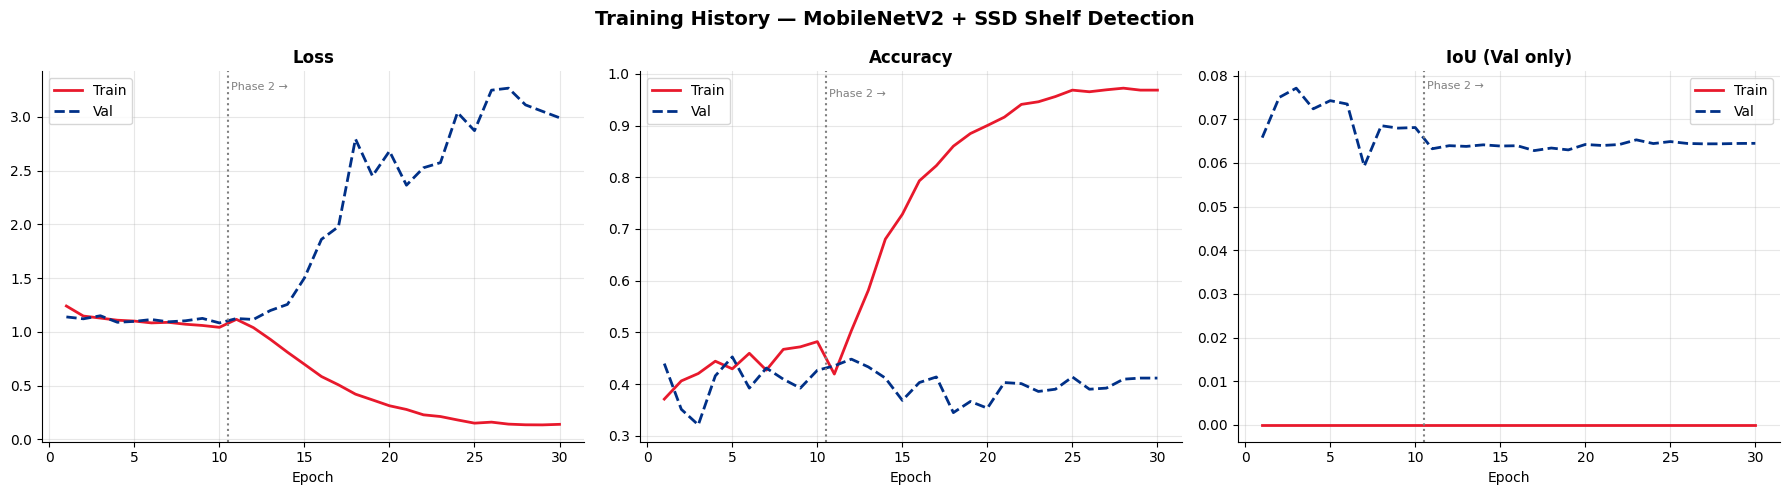

Training curves saved


In [9]:
# Load best weights
model.load_weights('best_model.weights.h5')
print(" Best weights loaded")

#Training curves
epochs   = range(1, len(history['train_loss']) + 1)
boundary = history['phase_boundary']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — MobileNetV2 + SSD Shelf Detection', fontsize=14, fontweight='bold')

for ax, (train_key, val_key, title) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy'),
    ('train_iou',  'val_iou',  'IoU (Val only)'),
]):
    ax.plot(epochs, history[train_key], color='#E8192C', lw=2, label='Train')
    ax.plot(epochs, history[val_key],   color='#003087', lw=2, label='Val', linestyle='--')
    if boundary:
        ax.axvline(x=boundary+0.5, color='gray', linestyle=':', lw=1.5)
        ax.text(boundary+0.7, ax.get_ylim()[1]*0.95, 'Phase 2 →', fontsize=8, color='gray')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved")

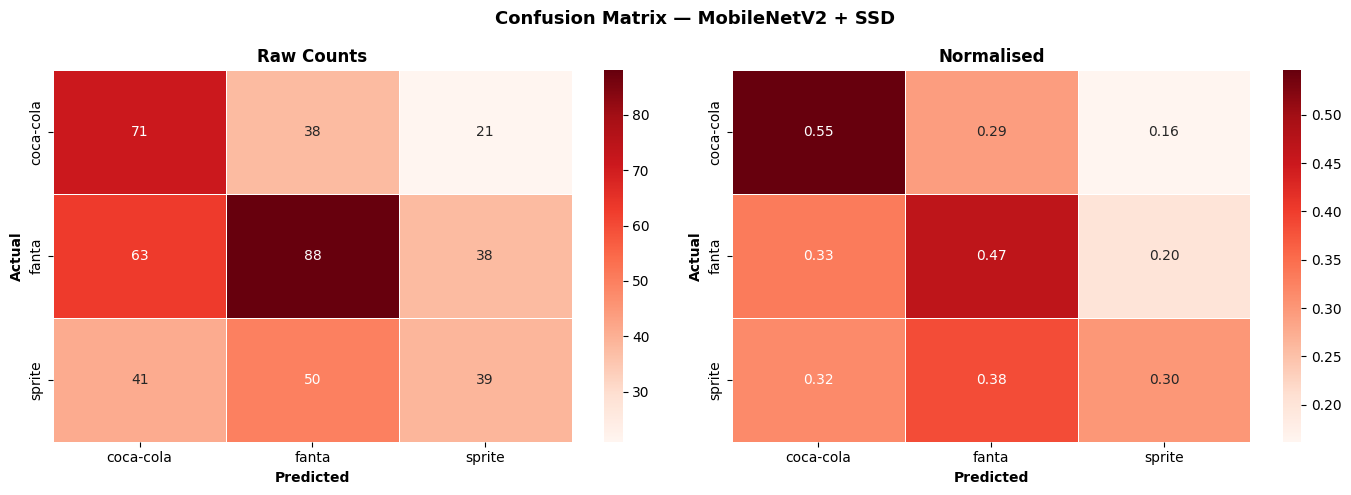


FINAL EVALUATION — MobileNetV2 + SSD
  Overall Accuracy : 44.10%
  Average IoU      : 0.068
  Best Val Loss    : 1.0829

  Class         Correct    Total      Acc
  ----------------------------------------
  coca-cola          71      130   54.62%
  fanta              88      189   46.56%
  sprite             39      130   30.00%


In [10]:
# Confusion matrix on validation set
all_preds, all_labels = [], []
val_ious_final = []

for images, cls_labels, bbox_labels in val_ds:
    outputs    = model(images, training=False)
    cls_preds  = outputs['classification']
    bbox_preds = outputs['bbox']
    all_preds.extend(tf.argmax(cls_preds,1).numpy())
    all_labels.extend(cls_labels.numpy())
    val_ious_final.append(compute_iou_tf(bbox_preds.numpy(), bbox_labels.numpy()))

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t][p] += 1
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — MobileNetV2 + SSD', fontsize=13, fontweight='bold')
for ax, (data, fmt, title) in zip(axes, [
    (cm,      'd',    'Raw Counts'),
    (cm_norm, '.2f',  'Normalised'),
]):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Reds', linewidths=0.5)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual',    fontweight='bold')
    ax.set_title(title,        fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final report
overall_acc = (all_preds == all_labels).mean()
avg_iou     = np.mean(val_ious_final)

print("\n" + "="*52)
print("FINAL EVALUATION — MobileNetV2 + SSD")
print("="*52)
print(f"  Overall Accuracy : {overall_acc:.2%}")
print(f"  Average IoU      : {avg_iou:.3f}")
print(f"  Best Val Loss    : {best_val_loss:.4f}")
print()
print(f"  {'Class':<12} {'Correct':>8} {'Total':>8} {'Acc':>8}")
print(f"  {'-'*40}")
for i, name in enumerate(CLASS_NAMES):
    correct = cm[i, i]
    total   = cm[i].sum()
    acc     = correct/total if total > 0 else 0
    print(f"  {name:<12} {correct:>8} {total:>8} {acc:>8.2%}")
print("="*52)

---
# STEP 8 — Run Inference on New Images

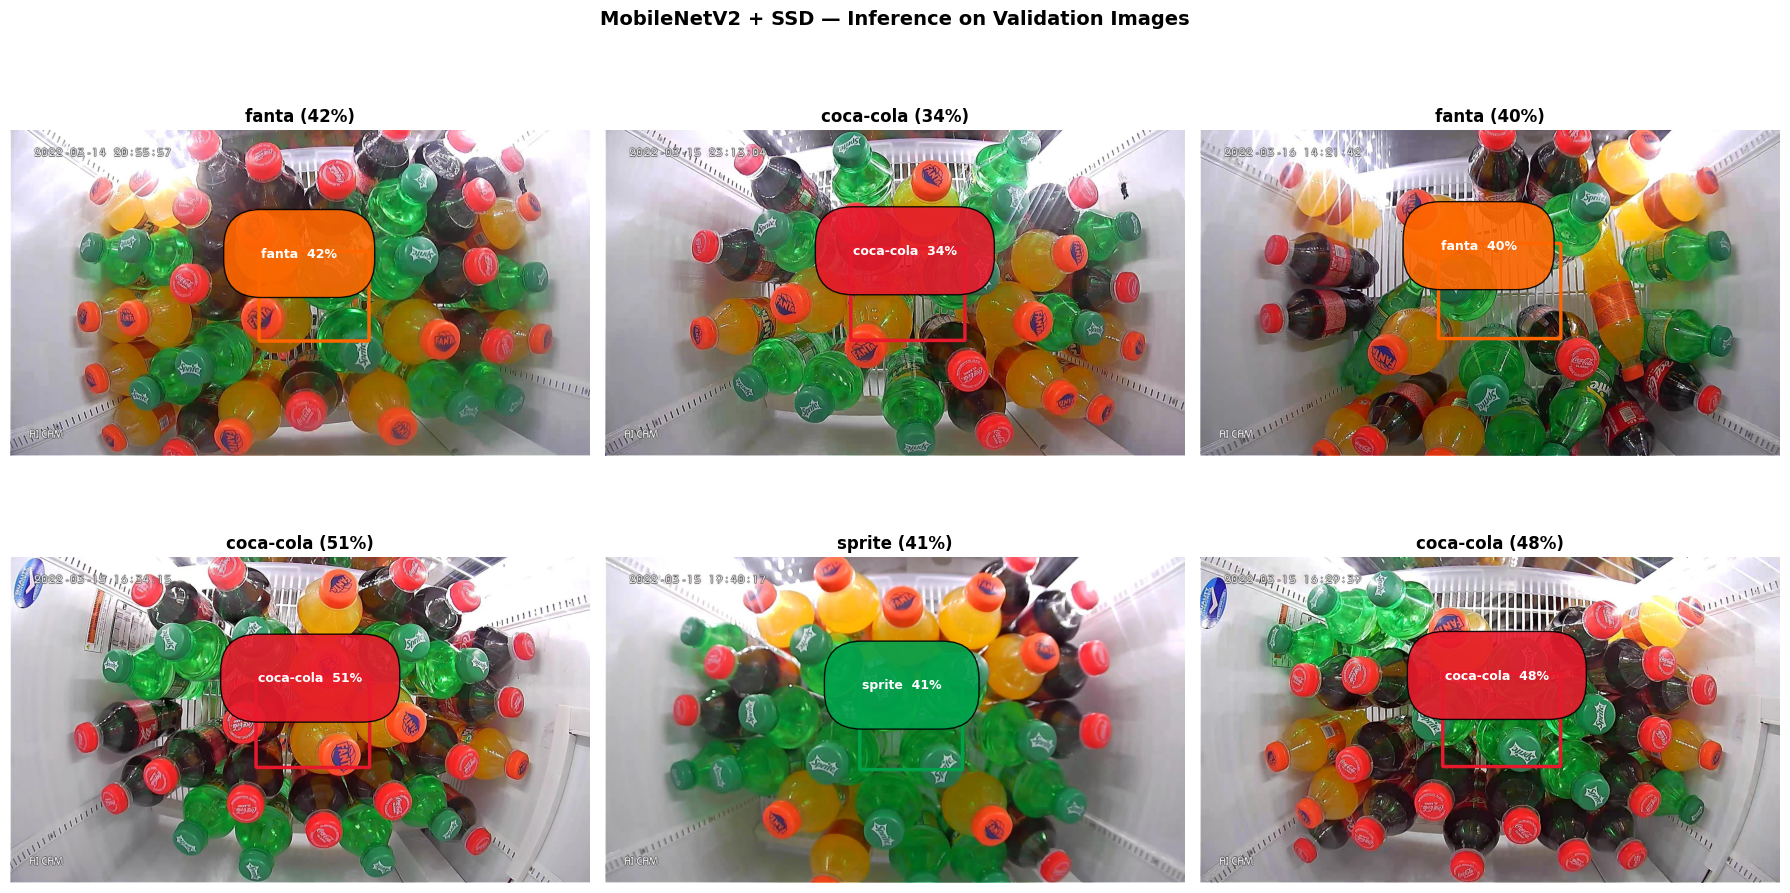

Inference results saved


In [11]:
def predict_image(image_path):
    img_orig = np.array(Image.open(image_path).convert('RGB'))
    H, W     = img_orig.shape[:2]

    # Preprocess (same as training)
    img = tf.image.resize(img_orig, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = tf.expand_dims(img, 0)  # add batch dimension

    outputs    = model(img, training=False)
    cls_probs  = outputs['classification'][0].numpy()
    bbox_norm  = outputs['bbox'][0].numpy()

    cls_id     = np.argmax(cls_probs)
    confidence = cls_probs[cls_id]
    name       = CLASS_NAMES[cls_id]

    cx, cy, bw, bh = bbox_norm
    x1 = int((cx - bw/2) * W)
    y1 = int((cy - bh/2) * H)
    x2 = int((cx + bw/2) * W)
    y2 = int((cy + bh/2) * H)

    return {"class": name, "confidence": confidence,
            "bbox_pixel": (x1,y1,x2,y2), "bbox_norm": bbox_norm,
            "all_probs": {CLASS_NAMES[i]: cls_probs[i] for i in range(NUM_CLASSES)}}


#Test on 6 validation images
val_img_dir = os.path.join(DATASET_DIR, 'valid', 'images')
val_imgs    = [f for f in os.listdir(val_img_dir) if f.endswith(('.jpg','.png'))]
test_imgs   = random.sample(val_imgs, min(6, len(val_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MobileNetV2 + SSD — Inference on Validation Images', fontsize=14, fontweight='bold')

for ax, img_name in zip(axes.flatten(), test_imgs):
    img_path = os.path.join(val_img_dir, img_name)
    result   = predict_image(img_path)
    img      = Image.open(img_path)

    ax.imshow(img)
    x1,y1,x2,y2 = result['bbox_pixel']
    color = COLORS_MAP.get(result['class'], '#999')
    ax.add_patch(patches.FancyBboxPatch((x1,y1), x2-x1, y2-y1,
                 boxstyle='round,pad=3', lw=2.5, edgecolor=color, facecolor='none'))
    ax.text(x1+4, y1+16, f"{result['class']}  {result['confidence']:.0%}",
            fontsize=9, color='white', fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.9, pad=3, boxstyle='round'))
    ax.axis('off')
    ax.set_title(f"{result['class']} ({result['confidence']:.0%})", fontweight='bold')

plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Inference results saved")

---
# STEP 9 — Shelf Metrics: SOS, OSA, Planogram

In [19]:
def analyze_shelf(image_path, conf_threshold=0.40):

    result = predict_image(image_path)

    cx, cy, bw, bh = result['bbox_norm']

    box_area = bw * bh

    brand_area = defaultdict(float)
    brand_count = defaultdict(int)

    if result['confidence'] >= conf_threshold:

        brand_area[result['class']] += box_area
        brand_count[result['class']] += 1

    for brand, prob in result['all_probs'].items():

        if prob > 0.10 and brand != result['class']:

            brand_area[brand] += box_area * prob

    total_area = sum(brand_area.values()) or 1.0

    sos = {
        name: (brand_area.get(name, 0) / total_area) * 100
        for name in CLASS_NAMES
    }

    osa = {
        name: (
            " Present"
            if brand_count.get(name, 0) > 0
            else " Out-of-Stock"
        )
        for name in CLASS_NAMES
    }

    dominant = max(sos, key=sos.get)

    planogram_ok = (dominant == 'coca-cola')

    print("\n" + "═"*55)
    print("     SHELF ANALYSIS — MobileNetV2 + SSD")
    print("═"*55)

    print(
        f"   Detected  : "
        f"{result['class']} "
        f"({result['confidence']*100:.1f}%)"
    )

    print()

    print("   Share of Shelf")

    for name in sorted(sos, key=sos.get, reverse=True):

        bar = '█' * int(sos[name] / 5)

        print(
            f"      {name:<12} "
            f"{sos[name]:5.1f}%  {bar}"
        )

    print()

    print("   On-Shelf Availability")

    for name in CLASS_NAMES:

        print(f"      {name:<12} {osa[name]}")

    badge = (
        ' COMPLIANT'
        if planogram_ok
        else f' NON-COMPLIANT ({dominant} dominates)'
    )

    print(f"\n   Planogram: {badge}")

    print("═"*55)


# Test on one image

test_img = os.path.join(val_img_dir, val_imgs[0])

analyze_shelf(test_img)


═══════════════════════════════════════════════════════
     SHELF ANALYSIS — MobileNetV2 + SSD
═══════════════════════════════════════════════════════
   Detected  : fanta (42.4%)

   Share of Shelf
      fanta         63.4%  ████████████
      coca-cola     19.2%  ███
      sprite        17.4%  ███

   On-Shelf Availability
      coca-cola     Out-of-Stock
      fanta         Present
      sprite        Out-of-Stock

   Planogram:  NON-COMPLIANT (fanta dominates)
═══════════════════════════════════════════════════════


---
# STEP 10 — Save & Download Everything

In [13]:
import os
import json
import numpy as np
from google.colab import files as colab_files

model.save("Samia_MobileNetV2+SSD_Model4.keras")
print("Full model saved as 'mobilenet_ssd_shelf_model.keras'")

def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

config = {
    "class_names": list(CLASS_NAMES),
    "num_classes": int(NUM_CLASSES),
    "img_size": list(IMG_SIZE) if isinstance(IMG_SIZE, tuple) else IMG_SIZE,
    "model_type": "MobileNetV2-SSD",
    "framework": "TensorFlow/Keras",
    "best_val_loss": float(best_val_loss),
    "final_val_acc": float(overall_acc),
    "final_val_iou": float(avg_iou),
    "preprocessing": "mobilenet_v2.preprocess_input (scales to [-1,1])"
}

with open("mobilenet_config.json", "w") as f:
    json.dump(config, f, indent=2, default=convert_numpy)

print("\nModel Config:")
print(json.dumps(config, indent=2, default=convert_numpy))

print("\n" + "=" * 55)
print("COMPLETE - MobileNetV2 + SSD")
print("=" * 55)
print(f"Best Val Loss : {best_val_loss:.4f}")
print(f"Val Accuracy  : {overall_acc:.2%}")
print(f"Val IoU       : {avg_iou:.3f}")

print("\nFiles:")
print("best_model.weights.h5")
print("mobilenet_ssd_shelf_model.keras")
print("mobilenet_config.json")
print("training_curves.png")
print("confusion_matrix.png")
print("inference_results.png")
print("=" * 55)

print("\nDownloading files...")

download_files = [
    "mobilenet_ssd_shelf_model.keras",
    "mobilenet_config.json",
    "training_curves.png",
    "confusion_matrix.png",
    "inference_results.png",
    "class_distribution.png",
    "sample_images.png"
]

for fname in download_files:
    if os.path.exists(fname):
        colab_files.download(fname)
        print(fname)
    else:
        print(f"{fname} not found")

print("\nDone")

Full model saved as 'mobilenet_ssd_shelf_model.keras'

Model Config:
{
  "class_names": [
    "coca-cola",
    "fanta",
    "sprite"
  ],
  "num_classes": 3,
  "img_size": 320,
  "model_type": "MobileNetV2-SSD",
  "framework": "TensorFlow/Keras",
  "best_val_loss": 1.082937240600586,
  "final_val_acc": 0.44097995545657015,
  "final_val_iou": 0.0680990219116211,
  "preprocessing": "mobilenet_v2.preprocess_input (scales to [-1,1])"
}

COMPLETE - MobileNetV2 + SSD
Best Val Loss : 1.0829
Val Accuracy  : 44.10%
Val IoU       : 0.068

Files:
best_model.weights.h5
mobilenet_ssd_shelf_model.keras
mobilenet_config.json
training_curves.png
confusion_matrix.png
inference_results.png

mobilenet_ssd_shelf_model.keras not found


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mobilenet_config.json


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

class_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sample_images.png

Done


---
## Summary

| Component | Role | Key Concept |
|-----------|------|-------------|
| **MobileNetV2 Backbone** | Fast feature extraction | Depthwise separable convolutions |
| **Global Avg Pooling** | Compress feature map → vector | Dimensionality reduction |
| **Classification Head** | Predicts brand (3 classes) | SparseCategoricalCrossentropy |
| **Bounding Box Head** | Predicts location [cx,cy,bw,bh] | Huber Loss + Sigmoid |
| **Phase 1** | Train head only (frozen backbone) | Transfer learning warm-up |
| **Phase 2** | Unfreeze last 30 backbone layers | Fine-tuning at low LR |
| **tf.data pipeline** | Efficient GPU data feeding | Prefetch + parallel loading |

